# 04 — Rolling Test Windows

Load saved NEAT & PPO models, run all 140-day test windows with the
weighted Supervisor, and compare ensemble vs. individual agents vs. buy-and-hold.

In [3]:
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import neat
import numpy as np
import pandas as pd
from stable_baselines3 import PPO

from hmats.agents import RSIAgent, SMACrossoverAgent
from hmats.agents.neat_agent import NEATAgent
from hmats.coordinator import Supervisor
from hmats.data.binance import fetch_binance_klines
from hmats.data.features import FEATURE_COLS, make_features
from hmats.data.splits import rolling_test_windows
from hmats.data.trading_env import (
    TradingEnv,
    TradingEnvConfig,
    buy_and_hold_metrics,
    evaluate_policy,
)

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-darkgrid")

SEED = 42

REPO_ROOT = Path.cwd().parents[2]
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = Path.cwd()
MODELS_DIR = REPO_ROOT / "models"
CONFIGS_DIR = REPO_ROOT / "configs"

## 1. Load data & models

In [4]:
# Data
raw = fetch_binance_klines(symbol="BTCUSDT", interval="1h", start="2021-01-01", end="2026-01-01")
feat_df = make_features(raw)
if isinstance(feat_df.index, pd.DatetimeIndex) and feat_df.index.tz is not None:
    feat_df.index = feat_df.index.tz_localize(None)

# Feature scaler (train-set stats)
scaler = np.load(MODELS_DIR / "feature_scaler.npz")
mu, sd = scaler["mu"], scaler["sd"]

# PPO model
ppo = PPO.load(str(MODELS_DIR / "ppo_model"))
print("PPO model loaded")

# NEAT model
neat_config = neat.Config(
    neat.DefaultGenome,
    neat.DefaultReproduction,
    neat.DefaultSpeciesSet,
    neat.DefaultStagnation,
    str(CONFIGS_DIR / "neat_trading.ini"),
)
with open(MODELS_DIR / "neat_winner.pkl", "rb") as f:
    winner_genome = pickle.load(f)
winner_net = neat.nn.FeedForwardNetwork.create(winner_genome, neat_config)
print("NEAT winner loaded")

PPO model loaded
NEAT winner loaded


## 2. Generate rolling 140-day test windows

In [5]:
TEST_START = "2025-01-01"
WINDOW_DAYS = 140

windows = rolling_test_windows(feat_df, start=TEST_START, window_days=WINDOW_DAYS)
print(f"Generated {len(windows)} test windows")
for i, w in enumerate(windows):
    print(f"  Window {i}: {w.index.min().date()} → {w.index.max().date()} ({len(w)} rows)")

Generated 3 test windows
  Window 0: 2025-01-01 → 2025-05-20 (3360 rows)
  Window 1: 2025-05-21 → 2025-10-07 (3360 rows)
  Window 2: 2025-10-08 → 2026-01-01 (2041 rows)


## 3. Evaluate each window

In [6]:
ENV_CFG = TradingEnvConfig(fee=0.0005, start_cash=1.0)

all_results = []

for wi, window_df in enumerate(windows):
    X_w = (window_df[FEATURE_COLS].values.astype(np.float32) - mu) / sd
    P_w = window_df["close"].values.astype(np.float32)

    # --- NEAT ---
    def neat_act(obs):
        return int(np.argmax(winner_net.activate(obs)))

    env_neat = TradingEnv(X_w, P_w, cfg=ENV_CFG, seed=SEED)
    neat_res = evaluate_policy(env_neat, neat_act, seed=SEED)

    # --- PPO ---
    def ppo_act(obs):
        action, _ = ppo.predict(obs, deterministic=True)
        return int(action)

    env_ppo = TradingEnv(X_w, P_w, cfg=ENV_CFG, seed=SEED)
    ppo_res = evaluate_policy(env_ppo, ppo_act, seed=SEED)

    # --- Buy & Hold ---
    bh_res = buy_and_hold_metrics(P_w, fee=ENV_CFG.fee)

    for method, res in [("NEAT", neat_res), ("PPO", ppo_res), ("Buy&Hold", bh_res)]:
        all_results.append(
            {
                "window": wi,
                "method": method,
                "start": window_df.index.min(),
                "end": window_df.index.max(),
                "final_equity": res["final_equity"],
                "total_return": res["total_return"],
                "sharpe": res["sharpe"],
                "max_drawdown": res["max_drawdown"],
                "num_trades": res["num_trades"],
            }
        )

results_df = pd.DataFrame(all_results)
results_df

,window,method,start,end,final_equity,total_return,sharpe,max_drawdown,num_trades
0,0,NEAT,2025-01-01,2025-05-20 23:00:00,0.997132,-0.002868,-0.051828,-0.066662,135
1,0,PPO,2025-01-01,2025-05-20 23:00:00,1.133918,0.133918,0.831266,-0.229400,148
2,0,Buy&Hold,2025-01-01,2025-05-20 23:00:00,1.130740,0.130740,0.610782,-0.309361,2
3,1,NEAT,2025-05-21,2025-10-07 23:00:00,0.897466,-0.102534,-1.873796,-0.144111,198
4,1,PPO,2025-05-21,2025-10-07 23:00:00,1.102602,0.102602,1.119571,-0.098625,143
5,1,Buy&Hold,2025-05-21,2025-10-07 23:00:00,1.135583,0.135583,1.048496,-0.132733,2
6,2,NEAT,2025-10-08,2026-01-01 00:00:00,0.859689,-0.140311,-4.179542,-0.176335,72
7,2,PPO,2025-10-08,2026-01-01 00:00:00,0.936620,-0.063380,-0.705530,-0.210828,123
8,2,Buy&Hold,2025-10-08,2026-01-01 00:00:00,0.719535,-0.280465,-3.002121,-0.337211,2


## 4. Per-window Sharpe comparison

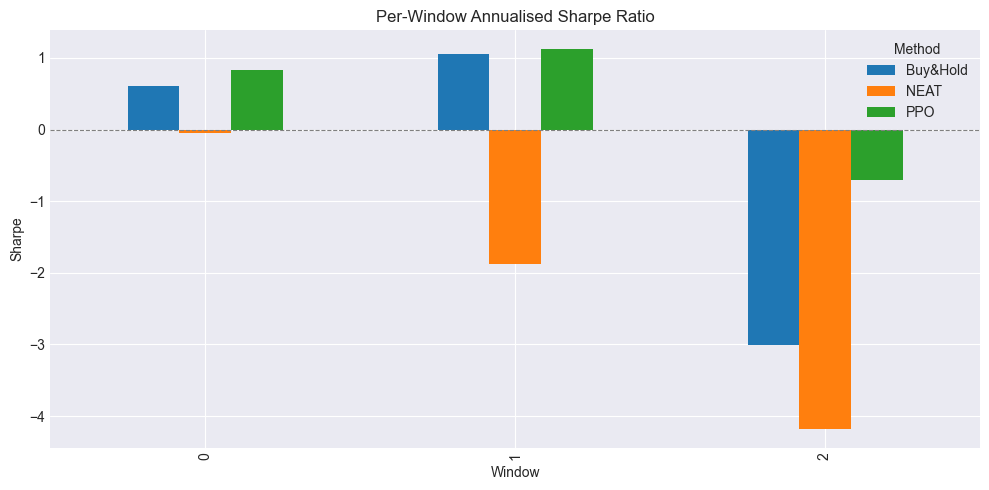

In [7]:
pivot = results_df.pivot(index="window", columns="method", values="sharpe")

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind="bar", ax=ax)
ax.set_title("Per-Window Annualised Sharpe Ratio")
ax.set_xlabel("Window")
ax.set_ylabel("Sharpe")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.legend(title="Method")
plt.tight_layout()
plt.show()

## 5. Aggregate metrics

In [8]:
summary = (
    results_df.groupby("method")
    .agg(
        mean_return=("total_return", "mean"),
        mean_sharpe=("sharpe", "mean"),
        worst_drawdown=("max_drawdown", "min"),
        total_trades=("num_trades", "sum"),
    )
    .round(4)
)
summary

,mean_return,mean_sharpe,worst_drawdown,total_trades
method,,,,
Buy&Hold,-0.0047,-0.4476,-0.3372,6
NEAT,-0.0819,-2.0351,-0.1763,405
PPO,0.0577,0.4151,-0.2294,414


## 6. Supervisor weighted-vote demo

Run the Supervisor step-by-step on the first test window with
`NEATAgent`, `SMACrossoverAgent`, and `RSIAgent`, calling
`update_outcome()` after each candle to let weights diverge.

In [9]:
from datetime import datetime

from hmats.agents.base import MarketSnapshot

neat_agent = NEATAgent(
    genome_path=MODELS_DIR / "neat_winner.pkl",
    config_path=CONFIGS_DIR / "neat_trading.ini",
)
sma_agent = SMACrossoverAgent()
rsi_agent = RSIAgent()

supervisor = Supervisor(agents=[neat_agent, sma_agent, rsi_agent], sharpe_window=30)

# Use first test window
w0 = windows[0]
X_w0 = (w0[FEATURE_COLS].values.astype(np.float32) - mu) / sd
P_w0 = w0["close"].values.astype(np.float32)

weight_history = []
decision_history = []
N_STEPS = min(200, len(w0) - 1)

for t in range(N_STEPS):
    # Build a minimal snapshot with NEAT-compatible indicators
    indicators = {k: float(X_w0[t, i]) for i, k in enumerate(FEATURE_COLS)}
    indicators["position_flag"] = 0.0
    indicators["cash_frac"] = 1.0

    # Also add daily-style indicators for SMA/RSI agents
    indicators["SMA_20"] = float(P_w0[t])  # pass-through for simple agents
    indicators["SMA_50"] = float(P_w0[t])
    indicators["RSI_14"] = indicators.get("rsi_14", 50.0) * 50.0 + 50.0  # de-standardise approx

    snapshot = MarketSnapshot(
        ticker="BTCUSDT",
        timestamp=datetime.now(),
        ohlcv=pd.DataFrame(),  # not used by these agents
        indicators=indicators,
    )

    decision = supervisor.run(snapshot)
    decision_history.append(decision)
    weight_history.append(supervisor.weights.copy())

    # Compute realised return for outcome scoring
    if t + 1 < len(P_w0):
        ret = float(np.log(P_w0[t + 1] / P_w0[t]))
        supervisor.update_outcome("BTCUSDT", ret)

print(f"\nFinal weights after {N_STEPS} steps:")
for aid, w in supervisor.weights.items():
    print(f"  {aid}: {w:.4f}")

2026-05-03 02:13:12.365 | INFO     | hmats.coordinator.supervisor:run:69 - Agent neat → sell (confidence=0.56, weight=0.333)
2026-05-03 02:13:12.366 | INFO     | hmats.coordinator.supervisor:run:69 - Agent sma_crossover → hold (confidence=0.00, weight=0.333)
2026-05-03 02:13:12.366 | INFO     | hmats.coordinator.supervisor:run:69 - Agent rsi_mean_reversion → hold (confidence=0.01, weight=0.333)
2026-05-03 02:13:12.367 | INFO     | hmats.coordinator.supervisor:run:92 - Decision → sell | confidence=0.56 | size=0.56
2026-05-03 02:13:12.368 | INFO     | hmats.coordinator.supervisor:run:69 - Agent neat → sell (confidence=0.79, weight=0.333)
2026-05-03 02:13:12.368 | INFO     | hmats.coordinator.supervisor:run:69 - Agent sma_crossover → hold (confidence=0.00, weight=0.333)
2026-05-03 02:13:12.369 | INFO     | hmats.coordinator.supervisor:run:69 - Agent rsi_mean_reversion → hold (confidence=0.01, weight=0.333)
2026-05-03 02:13:12.370 | INFO     | hmats.coordinator.supervisor:run:92 - Decision


Final weights after 200 steps:
  neat: 0.3538
  sma_crossover: 0.3231
  rsi_mean_reversion: 0.3231


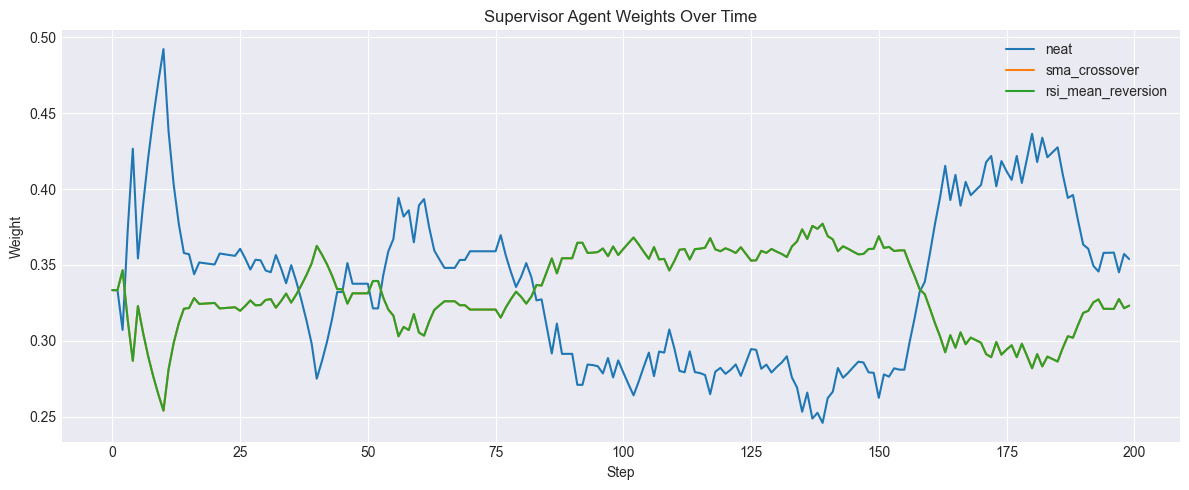

In [10]:
# Plot weight evolution
weight_df = pd.DataFrame(weight_history)

fig, ax = plt.subplots(figsize=(12, 5))
for col in weight_df.columns:
    ax.plot(weight_df[col], label=col)
ax.set_title("Supervisor Agent Weights Over Time")
ax.set_xlabel("Step")
ax.set_ylabel("Weight")
ax.legend()
plt.tight_layout()
plt.show()